# Exploratory Data Analysis - Northern Essentials Co.
## CPG Inventory & Supply Chain Dataset

This notebook explores the inventory and supply chain data for a fictional CPG company operating across 4 Canadian regions.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Data Loading

In [2]:
# Load all datasets
products = pd.read_csv('data/products.csv')
customers = pd.read_csv('data/customers.csv')
warehouses = pd.read_csv('data/warehouses.csv')
current_inventory = pd.read_csv('data/current_inventory.csv')
transactions = pd.read_csv('data/inventory_transactions.csv')
metrics = pd.read_csv('data/supply_chain_metrics.csv')

# Convert date columns
current_inventory['last_updated'] = pd.to_datetime(current_inventory['last_updated'])
transactions['date'] = pd.to_datetime(transactions['date'])
metrics['week_ending'] = pd.to_datetime(metrics['week_ending'])

print("✓ Data loaded successfully!")
print(f"\nDataset Sizes:")
print(f"  Products: {len(products):,} SKUs")
print(f"  Customers: {len(customers):,} retailers")
print(f"  Warehouses: {len(warehouses):,} distribution centers")
print(f"  Current Inventory: {len(current_inventory):,} records")
print(f"  Transactions: {len(transactions):,} records")
print(f"  Supply Chain Metrics: {len(metrics):,} records")

✓ Data loaded successfully!

Dataset Sizes:
  Products: 25 SKUs
  Customers: 10 retailers
  Warehouses: 13 distribution centers
  Current Inventory: 225 records
  Transactions: 9,202 records
  Supply Chain Metrics: 169 records


## 2. Product Catalog Analysis

In [3]:
# Product overview
print("=" * 60)
print("PRODUCT CATALOG OVERVIEW")
print("=" * 60)

print("\nProducts by Category:")
print(products.groupby('category').size().sort_values(ascending=False))

print("\n" + "-" * 60)
print("\nPricing Analysis by Category:")
pricing = products.groupby('category').agg({
    'unit_cost_cad': ['mean', 'min', 'max'],
    'retail_price_cad': ['mean', 'min', 'max']
}).round(2)
print(pricing)

# Calculate margins
products['margin_pct'] = ((products['retail_price_cad'] - products['unit_cost_cad']) / 
                          products['retail_price_cad'] * 100).round(1)

print("\n" + "-" * 60)
print("\nAverage Margin by Category:")
print(products.groupby('category')['margin_pct'].mean().sort_values(ascending=False).round(1))

PRODUCT CATALOG OVERVIEW

Products by Category:
category
Beverages                 5
Health & Wellness         5
Household Cleaning        5
Personal Care             5
Snacks & Confectionery    5
dtype: int64

------------------------------------------------------------

Pricing Analysis by Category:
                       unit_cost_cad            retail_price_cad            
                                mean  min   max             mean   min   max
category                                                                    
Beverages                       7.05 4.25  9.25            14.29  8.49 18.99
Health & Wellness              14.95 8.75 22.50            29.59 16.99 44.99
Household Cleaning             10.71 6.25 18.50            20.59 11.99 34.99
Personal Care                  10.65 6.50 15.75            20.79 12.99 29.99
Snacks & Confectionery          4.90 3.75  6.80             9.89  7.49 13.99

------------------------------------------------------------

Average Margin by 

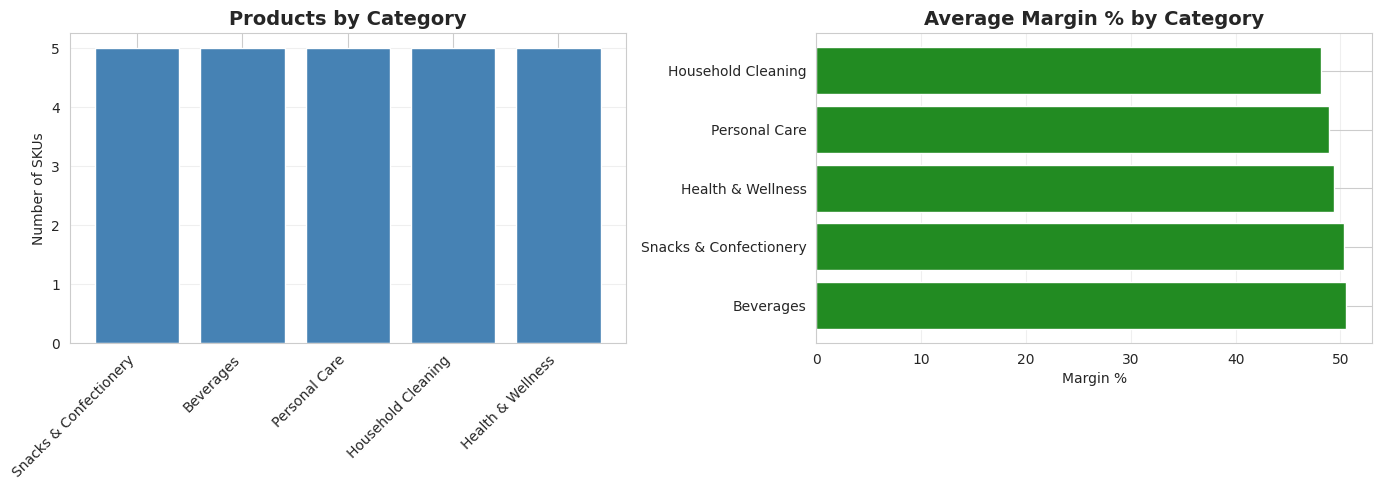

In [4]:
# Visualize product distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Products by category
category_counts = products['category'].value_counts()
axes[0].bar(range(len(category_counts)), category_counts.values, color='steelblue')
axes[0].set_xticks(range(len(category_counts)))
axes[0].set_xticklabels(category_counts.index, rotation=45, ha='right')
axes[0].set_title('Products by Category', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of SKUs')
axes[0].grid(axis='y', alpha=0.3)

# Margin by category
margin_by_cat = products.groupby('category')['margin_pct'].mean().sort_values(ascending=False)
axes[1].barh(range(len(margin_by_cat)), margin_by_cat.values, color='forestgreen')
axes[1].set_yticks(range(len(margin_by_cat)))
axes[1].set_yticklabels(margin_by_cat.index)
axes[1].set_title('Average Margin % by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Margin %')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Customer & Warehouse Analysis

In [5]:
print("=" * 60)
print("CUSTOMER ANALYSIS")
print("=" * 60)

print("\nCustomers by Type:")
print(customers['customer_type'].value_counts())

print("\nCustomers by Tier:")
print(customers['tier'].value_counts())

print("\n" + "-" * 60)
print("\nPayment Terms Distribution:")
print(customers['payment_terms_days'].value_counts().sort_index())

print("\n" + "-" * 60)
print("\nCredit Limit Statistics:")
print(f"  Mean: ${customers['credit_limit_cad'].mean():,.0f}")
print(f"  Median: ${customers['credit_limit_cad'].median():,.0f}")
print(f"  Total: ${customers['credit_limit_cad'].sum():,.0f}")

CUSTOMER ANALYSIS

Customers by Type:
customer_type
Grocery                4
Big Box                1
Warehouse Club         1
Pharmacy               1
Discount               1
General Merchandise    1
E-Commerce             1
Name: count, dtype: int64

Customers by Tier:
tier
National    9
Regional    1
Name: count, dtype: int64

------------------------------------------------------------

Payment Terms Distribution:
payment_terms_days
30    4
60    6
Name: count, dtype: int64

------------------------------------------------------------

Credit Limit Statistics:
  Mean: $2,913,988
  Median: $2,713,006
  Total: $29,139,884


In [6]:
print("=" * 60)
print("WAREHOUSE ANALYSIS")
print("=" * 60)

print("\nWarehouses by Region:")
print(warehouses['region'].value_counts())

print("\n" + "-" * 60)
print("\nCapacity & Utilization by Region:")
wh_summary = warehouses.groupby('region').agg({
    'warehouse_id': 'count',
    'capacity_pallets': 'sum',
    'current_utilization_pct': 'mean',
    'operating_cost_monthly_cad': 'sum',
    'staff_count': 'sum'
}).round(1)
wh_summary.columns = ['Warehouses', 'Total Capacity', 'Avg Utilization %', 'Monthly Costs CAD', 'Total Staff']
print(wh_summary)

print("\n" + "-" * 60)
print("\nWarehouse Utilization Statistics:")
print(f"  Mean: {warehouses['current_utilization_pct'].mean():.1f}%")
print(f"  Min: {warehouses['current_utilization_pct'].min():.1f}%")
print(f"  Max: {warehouses['current_utilization_pct'].max():.1f}%")

WAREHOUSE ANALYSIS

Warehouses by Region:
region
West        4
Atlantic    3
Ontario     3
Quebec      3
Name: count, dtype: int64

------------------------------------------------------------

Capacity & Utilization by Region:
          Warehouses  Total Capacity  Avg Utilization %  Monthly Costs CAD  \
region                                                                       
Atlantic           3           43584              70.90             535826   
Ontario            3           42916              73.00             313177   
Quebec             3           45277              74.20             325578   
West               4           42058              75.30             476809   

          Total Staff  
region                 
Atlantic          171  
Ontario           143  
Quebec            282  
West              234  

------------------------------------------------------------

Warehouse Utilization Statistics:
  Mean: 73.5%
  Min: 61.6%
  Max: 84.6%


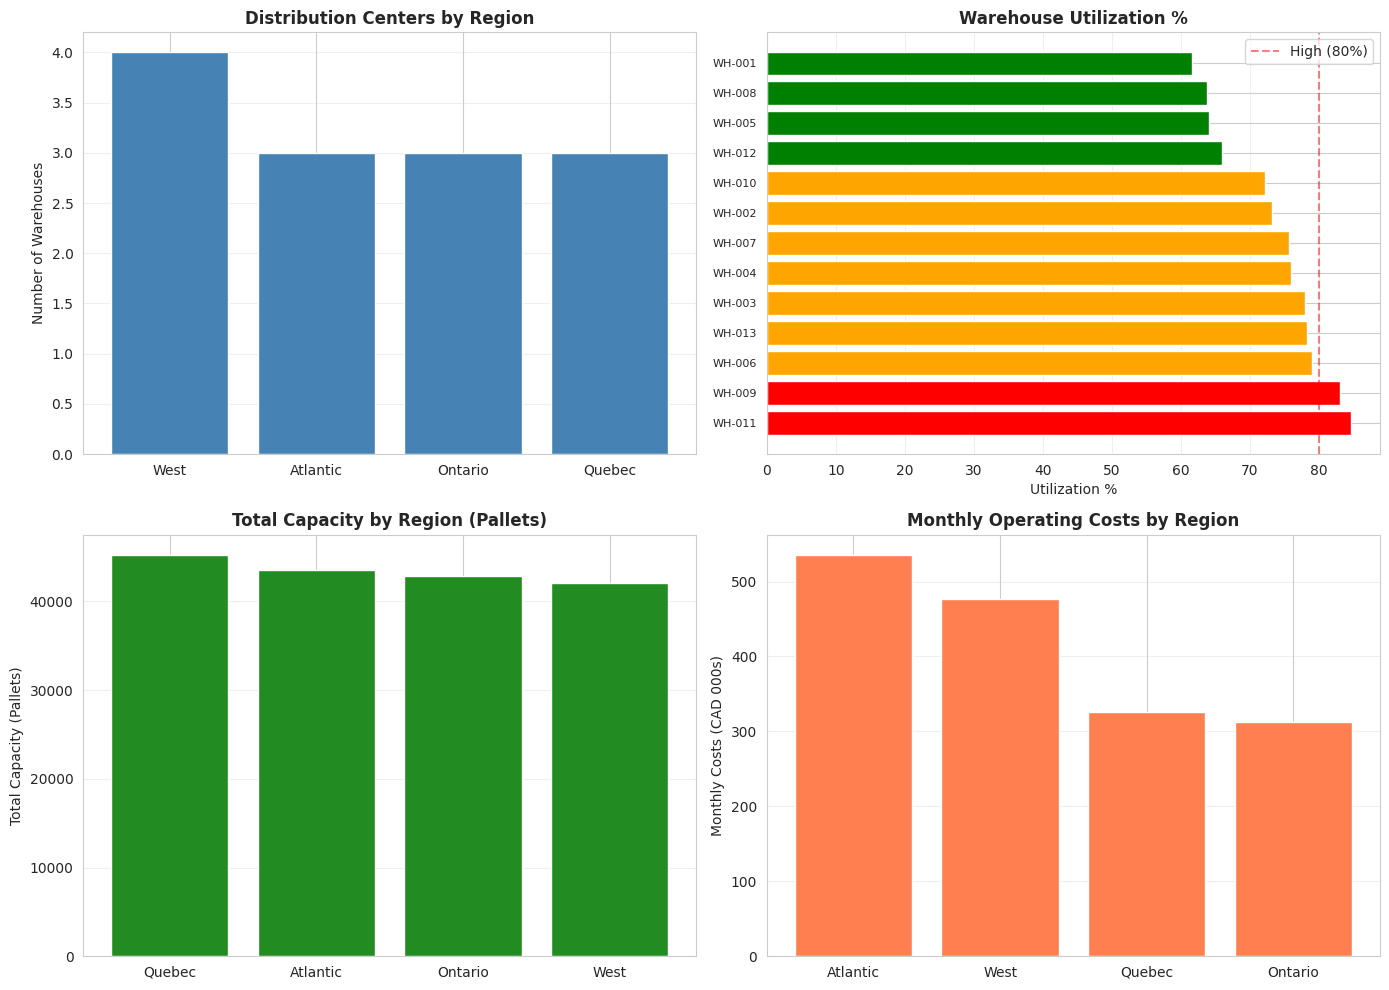

In [7]:
# Visualize warehouse metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Warehouses by region
region_counts = warehouses['region'].value_counts()
axes[0, 0].bar(region_counts.index, region_counts.values, color='steelblue')
axes[0, 0].set_title('Distribution Centers by Region', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Number of Warehouses')
axes[0, 0].grid(axis='y', alpha=0.3)

# Utilization by warehouse
wh_util = warehouses.sort_values('current_utilization_pct', ascending=False)
colors = ['red' if x > 80 else 'orange' if x > 70 else 'green' for x in wh_util['current_utilization_pct']]
axes[0, 1].barh(range(len(wh_util)), wh_util['current_utilization_pct'], color=colors)
axes[0, 1].set_yticks(range(len(wh_util)))
axes[0, 1].set_yticklabels(wh_util['warehouse_id'], fontsize=8)
axes[0, 1].set_title('Warehouse Utilization %', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Utilization %')
axes[0, 1].axvline(80, color='red', linestyle='--', alpha=0.5, label='High (80%)')
axes[0, 1].legend()
axes[0, 1].grid(axis='x', alpha=0.3)

# Capacity by region
capacity_by_region = warehouses.groupby('region')['capacity_pallets'].sum().sort_values(ascending=False)
axes[1, 0].bar(capacity_by_region.index, capacity_by_region.values, color='forestgreen')
axes[1, 0].set_title('Total Capacity by Region (Pallets)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Total Capacity (Pallets)')
axes[1, 0].grid(axis='y', alpha=0.3)

# Operating costs by region
costs_by_region = warehouses.groupby('region')['operating_cost_monthly_cad'].sum().sort_values(ascending=False)
axes[1, 1].bar(costs_by_region.index, costs_by_region.values / 1000, color='coral')
axes[1, 1].set_title('Monthly Operating Costs by Region', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Monthly Costs (CAD 000s)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Current Inventory Analysis

In [8]:
print("=" * 60)
print("CURRENT INVENTORY ANALYSIS")
print("=" * 60)

# Convert inventory value to numeric
current_inventory['inventory_value_cad'] = current_inventory['inventory_value_cad'].astype(float)

print("\nInventory Status Distribution:")
status_dist = current_inventory['status'].value_counts()
print(status_dist)
print(f"\n  Critical/Low: {(status_dist.get('Critical', 0) + status_dist.get('Low', 0)) / len(current_inventory) * 100:.1f}%")

print("\n" + "-" * 60)
print("\nTotal Inventory Value by Region:")
inv_by_region = current_inventory.groupby('region')['inventory_value_cad'].sum().sort_values(ascending=False)
for region, value in inv_by_region.items():
    print(f"  {region}: ${value:,.2f}")
print(f"\n  TOTAL: ${current_inventory['inventory_value_cad'].sum():,.2f}")

print("\n" + "-" * 60)
print("\nInventory Value by Category:")
inv_by_cat = current_inventory.groupby('category')['inventory_value_cad'].sum().sort_values(ascending=False)
for cat, value in inv_by_cat.items():
    print(f"  {cat}: ${value:,.2f}")

CURRENT INVENTORY ANALYSIS

Inventory Status Distribution:
status
Normal       145
Overstock     69
Low           11
Name: count, dtype: int64

  Critical/Low: 4.9%

------------------------------------------------------------

Total Inventory Value by Region:
  West: $1,983,039.95
  Ontario: $1,633,803.65
  Quebec: $1,490,149.10
  Atlantic: $1,243,596.25

  TOTAL: $6,350,588.95

------------------------------------------------------------

Inventory Value by Category:
  Health & Wellness: $2,037,003.00
  Household Cleaning: $1,321,262.55
  Personal Care: $1,207,916.25
  Beverages: $1,111,770.50
  Snacks & Confectionery: $672,636.65


In [9]:
print("\n" + "-" * 60)
print("\nDays of Supply Analysis:")
print(f"  Mean: {current_inventory['days_of_supply'].mean():.1f} days")
print(f"  Median: {current_inventory['days_of_supply'].median():.1f} days")
print(f"  Min: {current_inventory['days_of_supply'].min():.1f} days")
print(f"  Max: {current_inventory['days_of_supply'].max():.1f} days")

# Items with low days of supply
low_supply = current_inventory[current_inventory['days_of_supply'] < 7].sort_values('days_of_supply')
print(f"\nItems with < 7 days of supply: {len(low_supply)}")
if len(low_supply) > 0:
    print("\nTop 10 items needing attention:")
    print(low_supply[['warehouse_id', 'region', 'product_name', 'days_of_supply', 'status']].head(10).to_string(index=False))


------------------------------------------------------------

Days of Supply Analysis:
  Mean: 72.3 days
  Median: 50.6 days
  Min: 2.1 days
  Max: 604.1 days

Items with < 7 days of supply: 12

Top 10 items needing attention:
warehouse_id   region                product_name  days_of_supply    status
      WH-005  Ontario          Dish Soap - Citrus            2.10    Normal
      WH-002 Atlantic   Maple Crunch Granola Bars            2.60    Normal
      WH-012     West       Multi-Surface Cleaner            3.90    Normal
      WH-010     West      Toothpaste - Whitening            4.60       Low
      WH-003 Atlantic      Laundry Detergent Pods            4.80    Normal
      WH-002 Atlantic            Probiotics Daily            4.80    Normal
      WH-001 Atlantic        Hand Soap - Lavender            5.00    Normal
      WH-010     West Energy Drink - Arctic Blast            5.10    Normal
      WH-008   Quebec        Cold Brew Coffee RTD            5.70    Normal
      WH-006

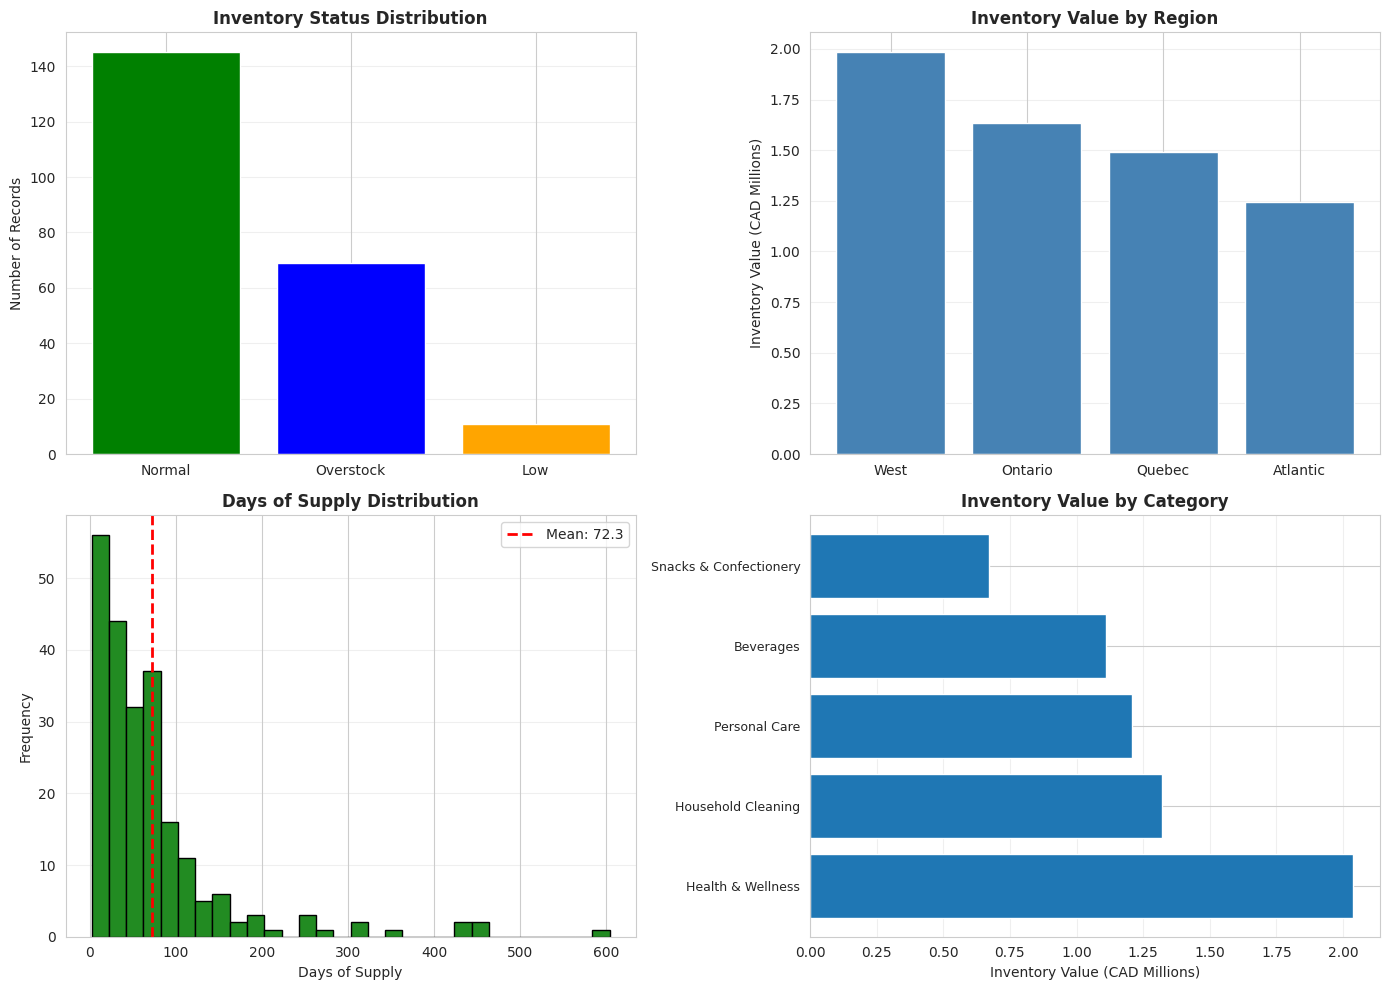

In [10]:
# Visualize inventory metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Inventory status distribution
status_counts = current_inventory['status'].value_counts()
colors_status = {'Normal': 'green', 'Low': 'orange', 'Critical': 'red', 'Overstock': 'blue'}
axes[0, 0].bar(status_counts.index, status_counts.values, 
               color=[colors_status.get(x, 'gray') for x in status_counts.index])
axes[0, 0].set_title('Inventory Status Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Number of Records')
axes[0, 0].grid(axis='y', alpha=0.3)

# Inventory value by region
inv_value_region = current_inventory.groupby('region')['inventory_value_cad'].sum().sort_values(ascending=False)
axes[0, 1].bar(inv_value_region.index, inv_value_region.values / 1000000, color='steelblue')
axes[0, 1].set_title('Inventory Value by Region', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Inventory Value (CAD Millions)')
axes[0, 1].grid(axis='y', alpha=0.3)

# Days of supply distribution
axes[1, 0].hist(current_inventory['days_of_supply'], bins=30, color='forestgreen', edgecolor='black')
axes[1, 0].axvline(current_inventory['days_of_supply'].mean(), color='red', 
                   linestyle='--', linewidth=2, label=f"Mean: {current_inventory['days_of_supply'].mean():.1f}")
axes[1, 0].set_title('Days of Supply Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Days of Supply')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Inventory value by category
inv_value_cat = current_inventory.groupby('category')['inventory_value_cad'].sum().sort_values(ascending=False)
axes[1, 1].barh(range(len(inv_value_cat)), inv_value_cat.values / 1000000)
axes[1, 1].set_yticks(range(len(inv_value_cat)))
axes[1, 1].set_yticklabels(inv_value_cat.index, fontsize=9)
axes[1, 1].set_title('Inventory Value by Category', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Inventory Value (CAD Millions)')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Transaction Analysis

In [11]:
print("=" * 60)
print("TRANSACTION ANALYSIS (90 Days)")
print("=" * 60)

# Convert total value to numeric
transactions['total_value_cad'] = transactions['total_value_cad'].astype(float)

print("\nTransaction Type Distribution:")
txn_types = transactions['transaction_type'].value_counts()
for txn_type, count in txn_types.items():
    pct = count / len(transactions) * 100
    print(f"  {txn_type}: {count:,} ({pct:.1f}%)")

print("\n" + "-" * 60)
print("\nTransaction Volume by Region:")
txn_by_region = transactions['region'].value_counts().sort_values(ascending=False)
for region, count in txn_by_region.items():
    print(f"  {region}: {count:,}")

print("\n" + "-" * 60)
print("\nTotal Transaction Value by Type:")
txn_value_type = transactions.groupby('transaction_type')['total_value_cad'].sum().sort_values(ascending=False)
for txn_type, value in txn_value_type.items():
    print(f"  {txn_type}: ${value:,.2f}")

TRANSACTION ANALYSIS (90 Days)

Transaction Type Distribution:
  Outbound: 4,665 (50.7%)
  Inbound: 2,795 (30.4%)
  Transfer: 1,259 (13.7%)
  Adjustment: 483 (5.2%)

------------------------------------------------------------

Transaction Volume by Region:
  West: 2,918
  Quebec: 2,127
  Ontario: 2,089
  Atlantic: 2,068

------------------------------------------------------------

Total Transaction Value by Type:
  Inbound: $47,689,247.45
  Outbound: $35,735,746.70
  Transfer: $3,607,294.70
  Adjustment: $107,842.20


In [12]:
# Daily transaction trends
daily_txn = transactions.groupby('date').agg({
    'transaction_id': 'count',
    'total_value_cad': 'sum'
}).reset_index()
daily_txn.columns = ['date', 'transaction_count', 'total_value']

# Weekly rolling average
daily_txn['rolling_avg_count'] = daily_txn['transaction_count'].rolling(window=7).mean()
daily_txn['rolling_avg_value'] = daily_txn['total_value'].rolling(window=7).mean()

print("\n" + "-" * 60)
print("\nDaily Transaction Statistics:")
print(f"  Avg transactions/day: {daily_txn['transaction_count'].mean():.0f}")
print(f"  Min transactions/day: {daily_txn['transaction_count'].min():.0f}")
print(f"  Max transactions/day: {daily_txn['transaction_count'].max():.0f}")
print(f"\n  Avg value/day: ${daily_txn['total_value'].mean():,.2f}")
print(f"  Total value (90 days): ${daily_txn['total_value'].sum():,.2f}")


------------------------------------------------------------

Daily Transaction Statistics:
  Avg transactions/day: 101
  Min transactions/day: 51
  Max transactions/day: 149

  Avg value/day: $957,583.86
  Total value (90 days): $87,140,131.05


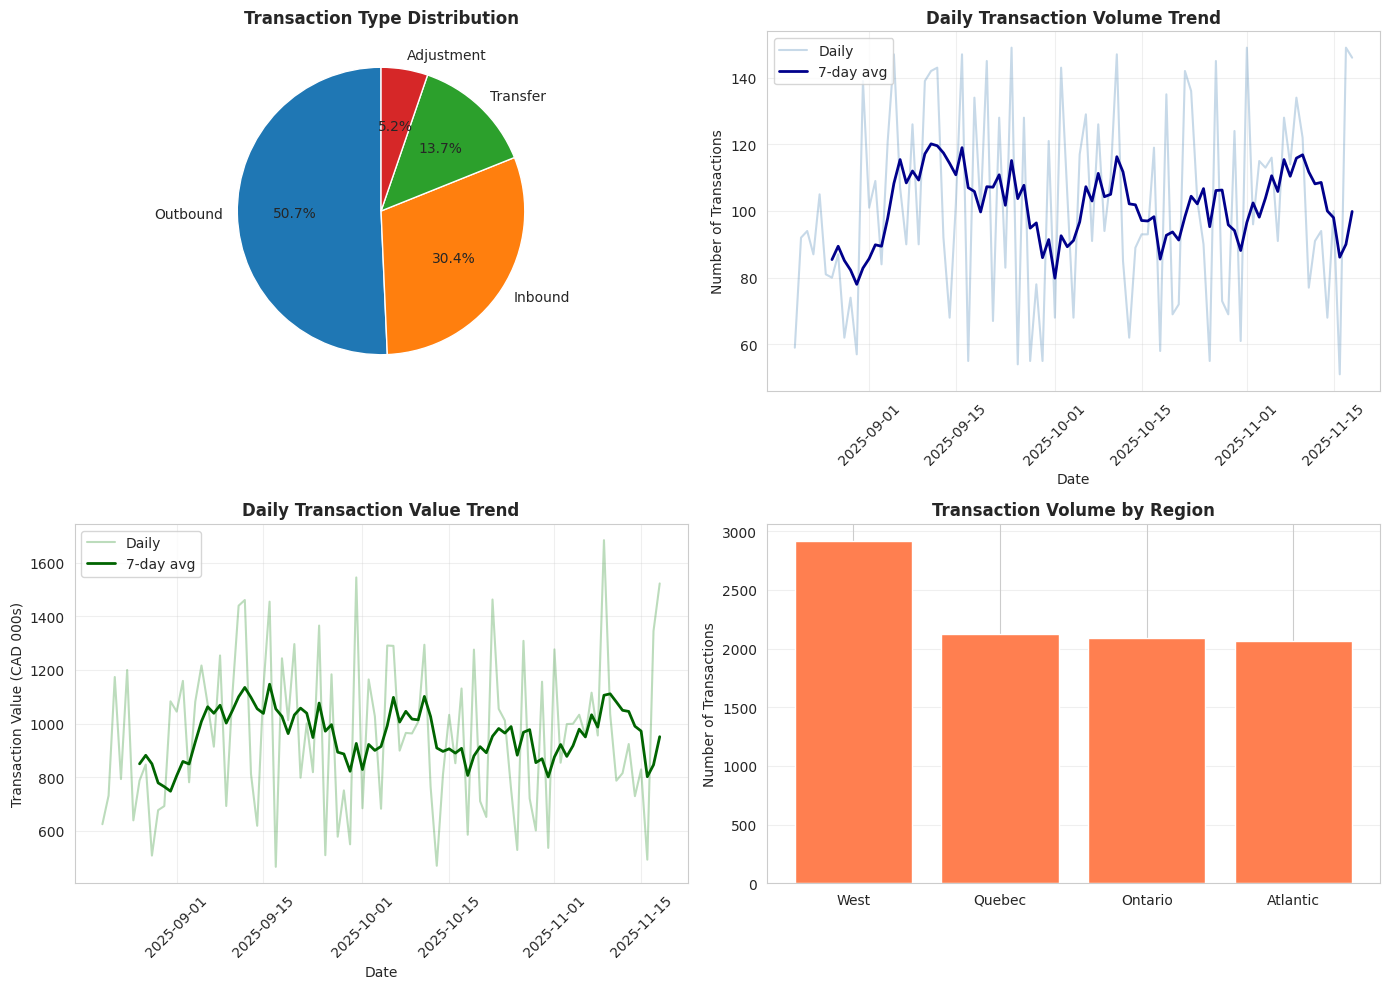

In [13]:
# Visualize transaction trends
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Transaction type distribution
txn_type_counts = transactions['transaction_type'].value_counts()
axes[0, 0].pie(txn_type_counts.values, labels=txn_type_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Transaction Type Distribution', fontsize=12, fontweight='bold')

# Daily transaction volume over time
axes[0, 1].plot(daily_txn['date'], daily_txn['transaction_count'], alpha=0.3, color='steelblue', label='Daily')
axes[0, 1].plot(daily_txn['date'], daily_txn['rolling_avg_count'], color='darkblue', linewidth=2, label='7-day avg')
axes[0, 1].set_title('Daily Transaction Volume Trend', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Number of Transactions')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# Transaction value over time
axes[1, 0].plot(daily_txn['date'], daily_txn['total_value'] / 1000, alpha=0.3, color='forestgreen', label='Daily')
axes[1, 0].plot(daily_txn['date'], daily_txn['rolling_avg_value'] / 1000, color='darkgreen', linewidth=2, label='7-day avg')
axes[1, 0].set_title('Daily Transaction Value Trend', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Transaction Value (CAD 000s)')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Transactions by region
txn_region_counts = transactions['region'].value_counts()
axes[1, 1].bar(txn_region_counts.index, txn_region_counts.values, color='coral')
axes[1, 1].set_title('Transaction Volume by Region', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Number of Transactions')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Outbound transactions by customer
outbound = transactions[transactions['transaction_type'] == 'Outbound']
outbound_with_customer = outbound[outbound['customer_id'] != '']

print("\n" + "=" * 60)
print("CUSTOMER SHIPMENT ANALYSIS")
print("=" * 60)

if len(outbound_with_customer) > 0:
    customer_shipments = outbound_with_customer.groupby('customer_id').agg({
        'transaction_id': 'count',
        'quantity': lambda x: abs(x).sum(),
        'total_value_cad': 'sum'
    }).sort_values('total_value_cad', ascending=False)
    customer_shipments.columns = ['Shipments', 'Total Units', 'Total Value CAD']
    
    print("\nTop Customers by Shipment Value:")
    print(customer_shipments.head(10))
else:
    print("No customer shipment data available.")


CUSTOMER SHIPMENT ANALYSIS

Top Customers by Shipment Value:
             Shipments  Total Units  Total Value CAD
customer_id                                         
C008               513       394498       3931072.00
C007               466       368961       3751728.10
C002               463       375553       3674932.95
C003               466       387302       3672260.35
C001               481       378691       3665828.85
C005               470       370075       3592914.35
C010               456       364250       3540882.60
C004               458       365446       3347324.95
C009               434       325760       3049325.15
C006               203       160380       1521521.30


## 6. Supply Chain KPI Analysis

In [15]:
print("=" * 60)
print("SUPPLY CHAIN PERFORMANCE METRICS (90 Days)")
print("=" * 60)

print("\nOverall KPIs:")
print(f"  Avg Order Fill Rate: {metrics['order_fill_rate_pct'].mean():.2f}%")
print(f"  Avg On-Time Delivery: {metrics['on_time_delivery_pct'].mean():.2f}%")
print(f"  Avg Lead Time: {metrics['avg_lead_time_days'].mean():.2f} days")
print(f"  Avg Inventory Accuracy: {metrics['inventory_accuracy_pct'].mean():.2f}%")
print(f"  Avg Picking Accuracy: {metrics['picking_accuracy_pct'].mean():.2f}%")
print(f"  Total Stockout Incidents: {metrics['stockout_incidents'].sum():.0f}")

print("\n" + "-" * 60)
print("\nKPIs by Region:")
kpi_by_region = metrics.groupby('region').agg({
    'order_fill_rate_pct': 'mean',
    'on_time_delivery_pct': 'mean',
    'avg_lead_time_days': 'mean',
    'stockout_incidents': 'sum',
    'inventory_accuracy_pct': 'mean'
}).round(2)
kpi_by_region.columns = ['Fill Rate %', 'On-Time %', 'Lead Time (days)', 'Stockouts', 'Inv Accuracy %']
print(kpi_by_region)

print("\n" + "-" * 60)
print("\nOrders Processed:")
order_summary = metrics.groupby('region').agg({
    'orders_received': 'sum',
    'orders_fulfilled': 'sum'
})
order_summary['fulfillment_rate'] = (order_summary['orders_fulfilled'] / order_summary['orders_received'] * 100).round(2)
print(order_summary)

SUPPLY CHAIN PERFORMANCE METRICS (90 Days)

Overall KPIs:
  Avg Order Fill Rate: 95.94%
  Avg On-Time Delivery: 92.04%
  Avg Lead Time: 3.27 days
  Avg Inventory Accuracy: 97.91%
  Avg Picking Accuracy: 98.51%
  Total Stockout Incidents: 420

------------------------------------------------------------

KPIs by Region:
          Fill Rate %  On-Time %  Lead Time (days)  Stockouts  Inv Accuracy %
region                                                                       
Atlantic        96.77      92.21              3.40         90           97.93
Ontario         95.30      92.04              3.15        112           98.01
Quebec          95.94      91.69              3.14         95           97.85
West            95.79      92.18              3.35        123           97.87

------------------------------------------------------------

Orders Processed:
          orders_received  orders_fulfilled  fulfillment_rate
region                                                       
Atlant

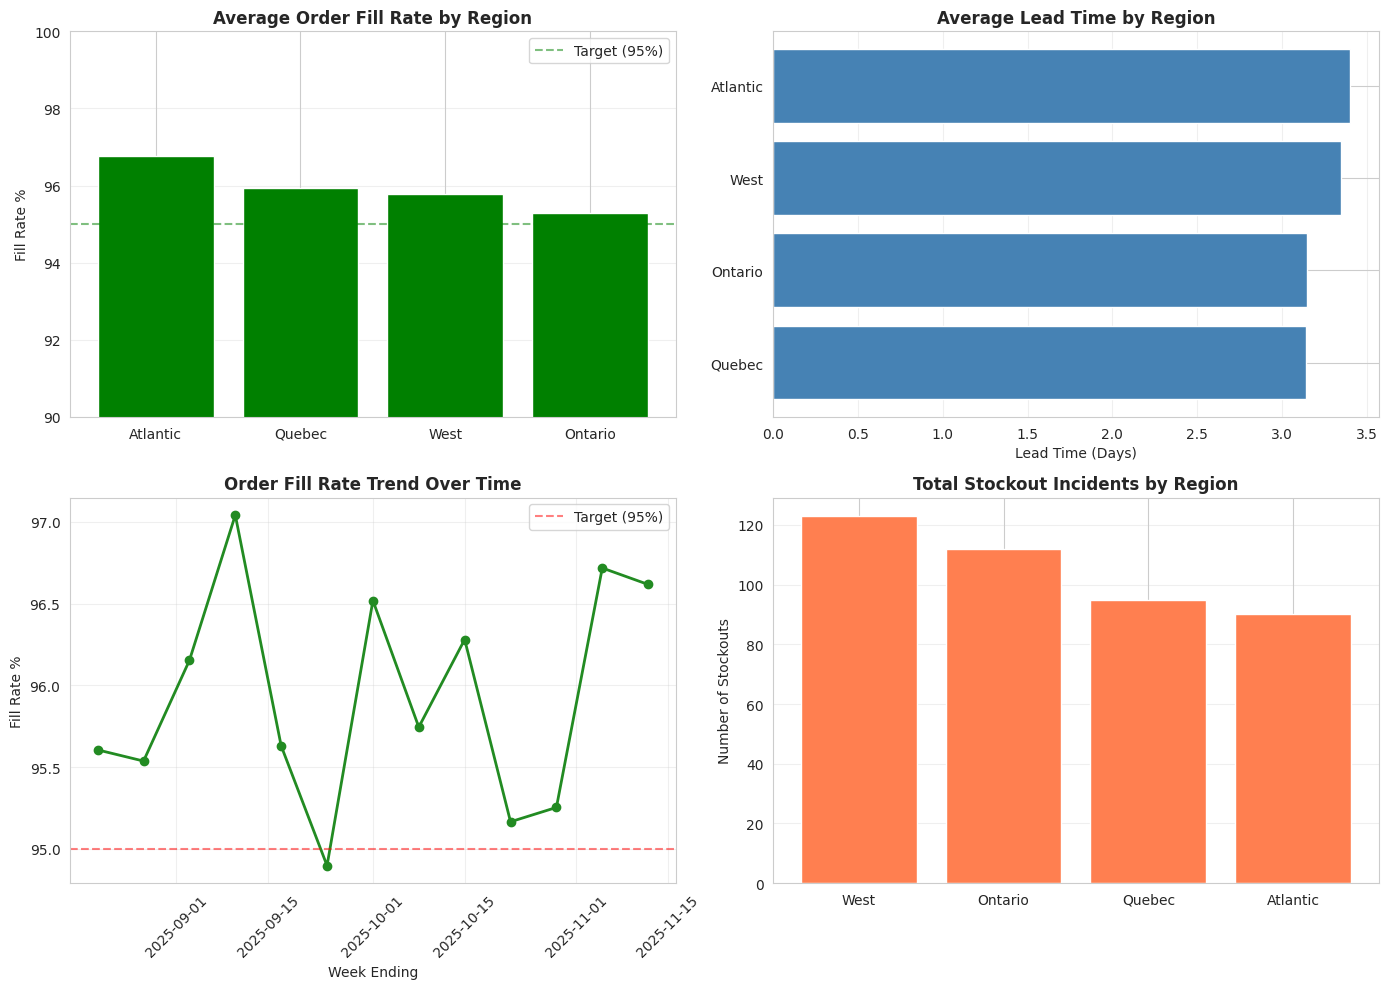

In [16]:
# Visualize supply chain metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Fill rate by region
fill_rate_region = metrics.groupby('region')['order_fill_rate_pct'].mean().sort_values(ascending=False)
colors_fill = ['green' if x > 95 else 'orange' if x > 90 else 'red' for x in fill_rate_region.values]
axes[0, 0].bar(fill_rate_region.index, fill_rate_region.values, color=colors_fill)
axes[0, 0].axhline(95, color='green', linestyle='--', alpha=0.5, label='Target (95%)')
axes[0, 0].set_title('Average Order Fill Rate by Region', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Fill Rate %')
axes[0, 0].set_ylim([90, 100])
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Lead time by region
lead_time_region = metrics.groupby('region')['avg_lead_time_days'].mean().sort_values()
axes[0, 1].barh(range(len(lead_time_region)), lead_time_region.values, color='steelblue')
axes[0, 1].set_yticks(range(len(lead_time_region)))
axes[0, 1].set_yticklabels(lead_time_region.index)
axes[0, 1].set_title('Average Lead Time by Region', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Lead Time (Days)')
axes[0, 1].grid(axis='x', alpha=0.3)

# Fill rate trend over time
fill_rate_trend = metrics.groupby('week_ending')['order_fill_rate_pct'].mean().reset_index()
axes[1, 0].plot(fill_rate_trend['week_ending'], fill_rate_trend['order_fill_rate_pct'], 
                marker='o', linewidth=2, color='forestgreen')
axes[1, 0].axhline(95, color='red', linestyle='--', alpha=0.5, label='Target (95%)')
axes[1, 0].set_title('Order Fill Rate Trend Over Time', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Week Ending')
axes[1, 0].set_ylabel('Fill Rate %')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Stockout incidents by region
stockouts_region = metrics.groupby('region')['stockout_incidents'].sum().sort_values(ascending=False)
axes[1, 1].bar(stockouts_region.index, stockouts_region.values, color='coral')
axes[1, 1].set_title('Total Stockout Incidents by Region', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Number of Stockouts')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Regional Comparison

In [17]:
print("=" * 60)
print("COMPREHENSIVE REGIONAL COMPARISON")
print("=" * 60)

# Build comprehensive regional summary
regional_summary = pd.DataFrame()

# Warehouses
regional_summary['Warehouses'] = warehouses.groupby('region')['warehouse_id'].count()
regional_summary['Total Capacity'] = warehouses.groupby('region')['capacity_pallets'].sum()
regional_summary['Avg Utilization %'] = warehouses.groupby('region')['current_utilization_pct'].mean().round(1)

# Inventory
regional_summary['SKU Count'] = current_inventory.groupby('region')['sku'].nunique()
regional_summary['Inv Value (M CAD)'] = (current_inventory.groupby('region')['inventory_value_cad'].sum() / 1000000).round(2)
regional_summary['Avg Days Supply'] = current_inventory.groupby('region')['days_of_supply'].mean().round(1)

# Transactions
regional_summary['Total Transactions'] = transactions.groupby('region')['transaction_id'].count()

# KPIs
regional_summary['Fill Rate %'] = metrics.groupby('region')['order_fill_rate_pct'].mean().round(2)
regional_summary['On-Time %'] = metrics.groupby('region')['on_time_delivery_pct'].mean().round(2)
regional_summary['Stockouts'] = metrics.groupby('region')['stockout_incidents'].sum()

print("\n", regional_summary.sort_values('Inv Value (M CAD)', ascending=False))

COMPREHENSIVE REGIONAL COMPARISON

           Warehouses  Total Capacity  Avg Utilization %  SKU Count  \
region                                                               
West               4           42058              75.30         24   
Ontario            3           42916              73.00         25   
Quebec             3           45277              74.20         23   
Atlantic           3           43584              70.90         25   

          Inv Value (M CAD)  Avg Days Supply  Total Transactions  Fill Rate %  \
region                                                                          
West                   1.98            80.90                2918        95.79   
Ontario                1.63            62.70                2089        95.30   
Quebec                 1.49            76.50                2127        95.94   
Atlantic               1.24            67.60                2068        96.77   

          On-Time %  Stockouts  
region                 

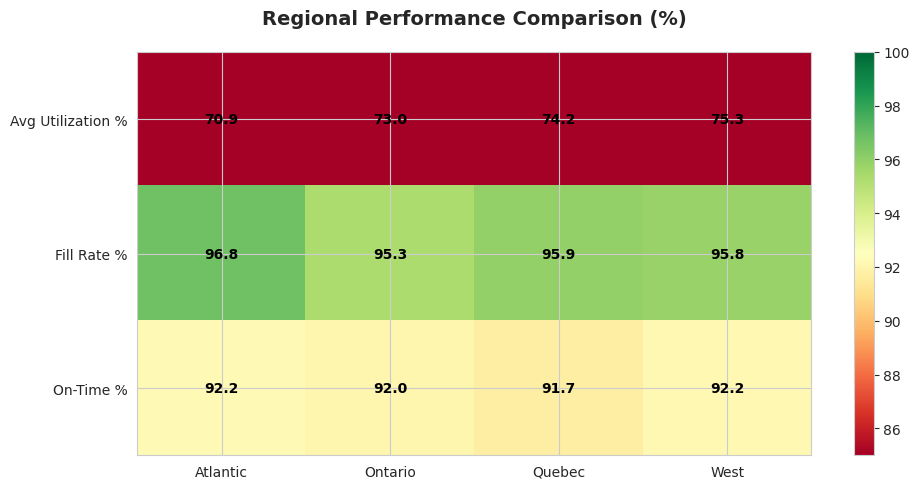

In [18]:
# Regional performance heatmap
import matplotlib.colors as mcolors

# Normalize metrics for comparison (0-100 scale)
comparison_metrics = regional_summary[['Avg Utilization %', 'Fill Rate %', 'On-Time %']].copy()

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(comparison_metrics.T, cmap='RdYlGn', aspect='auto', vmin=85, vmax=100)

# Set ticks and labels
ax.set_xticks(range(len(comparison_metrics.index)))
ax.set_xticklabels(comparison_metrics.index)
ax.set_yticks(range(len(comparison_metrics.columns)))
ax.set_yticklabels(comparison_metrics.columns)

# Add values in cells
for i in range(len(comparison_metrics.columns)):
    for j in range(len(comparison_metrics.index)):
        text = ax.text(j, i, f"{comparison_metrics.iloc[j, i]:.1f}",
                      ha="center", va="center", color="black", fontweight='bold')

ax.set_title('Regional Performance Comparison (%)', fontsize=14, fontweight='bold', pad=20)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 8. Key Insights & Recommendations

In [19]:
print("=" * 60)
print("KEY INSIGHTS & RECOMMENDATIONS")
print("=" * 60)

# Calculate key metrics
critical_low_items = current_inventory[current_inventory['status'].isin(['Critical', 'Low'])]
overstock_items = current_inventory[current_inventory['status'] == 'Overstock']
high_util_warehouses = warehouses[warehouses['current_utilization_pct'] > 80]
low_fill_rate_regions = kpi_by_region[kpi_by_region['Fill Rate %'] < 95].index.tolist()

print("\n📊 INVENTORY INSIGHTS:")
print(f"  • Total inventory value: ${current_inventory['inventory_value_cad'].sum():,.2f}")
print(f"  • Critical/Low stock items: {len(critical_low_items)} ({len(critical_low_items)/len(current_inventory)*100:.1f}%)")
print(f"  • Overstock items: {len(overstock_items)} ({len(overstock_items)/len(current_inventory)*100:.1f}%)")
print(f"  • Average days of supply: {current_inventory['days_of_supply'].mean():.1f} days")

print("\n🏭 WAREHOUSE CAPACITY:")
print(f"  • Average utilization: {warehouses['current_utilization_pct'].mean():.1f}%")
print(f"  • High utilization (>80%) warehouses: {len(high_util_warehouses)}/{len(warehouses)}")
if len(high_util_warehouses) > 0:
    print(f"  • Warehouses needing attention: {', '.join(high_util_warehouses['warehouse_id'].tolist())}")

print("\n📦 SUPPLY CHAIN PERFORMANCE:")
print(f"  • Average fill rate: {metrics['order_fill_rate_pct'].mean():.2f}%")
print(f"  • Average on-time delivery: {metrics['on_time_delivery_pct'].mean():.2f}%")
print(f"  • Average lead time: {metrics['avg_lead_time_days'].mean():.2f} days")
print(f"  • Total stockout incidents: {metrics['stockout_incidents'].sum():.0f}")
if len(low_fill_rate_regions) > 0:
    print(f"  • Regions below 95% fill rate: {', '.join(low_fill_rate_regions)}")

print("\n💡 RECOMMENDATIONS:")
print("\n1. INVENTORY OPTIMIZATION:")
if len(critical_low_items) > 0:
    print(f"   • Prioritize replenishment for {len(critical_low_items)} critical/low items")
    top_critical = critical_low_items.nsmallest(5, 'days_of_supply')
    print(f"   • Most urgent: {', '.join(top_critical['product_name'].unique()[:3])}")
if len(overstock_items) > 0:
    print(f"   • Review and potentially discount {len(overstock_items)} overstocked items")

print("\n2. WAREHOUSE MANAGEMENT:")
if len(high_util_warehouses) > 0:
    print(f"   • Consider capacity expansion or redistribution for high-utilization warehouses")
    # Sort by utilization to get the highest ones
    top_warehouses = high_util_warehouses.sort_values('current_utilization_pct', ascending=False).head(3)
    print(f"   • Focus on: {', '.join(top_warehouses['city'].tolist())}")

print("\n3. SUPPLY CHAIN IMPROVEMENTS:")
if len(low_fill_rate_regions) > 0:
    print(f"   • Investigate fill rate issues in {', '.join(low_fill_rate_regions)}")
high_stockout_regions = metrics.groupby('region')['stockout_incidents'].sum().nlargest(2)
if len(high_stockout_regions) > 0:
    print(f"   • Address stockout patterns in: {', '.join(high_stockout_regions.index.tolist())}")
print(f"   • Target lead time reduction from {metrics['avg_lead_time_days'].mean():.1f} to <3 days")

print("\n4. REGIONAL FOCUS:")
best_region = kpi_by_region['Fill Rate %'].idxmax()
print(f"   • Share best practices from {best_region} (highest fill rate) with other regions")
print(f"   • Align inventory policies across regions to maintain {current_inventory['days_of_supply'].mean():.0f}+ days supply")

print("\n" + "=" * 60)

KEY INSIGHTS & RECOMMENDATIONS

📊 INVENTORY INSIGHTS:
  • Total inventory value: $6,350,588.95
  • Critical/Low stock items: 11 (4.9%)
  • Overstock items: 69 (30.7%)
  • Average days of supply: 72.3 days

🏭 WAREHOUSE CAPACITY:
  • Average utilization: 73.5%
  • High utilization (>80%) warehouses: 2/13
  • Warehouses needing attention: WH-009, WH-011

📦 SUPPLY CHAIN PERFORMANCE:
  • Average fill rate: 95.94%
  • Average on-time delivery: 92.04%
  • Average lead time: 3.27 days
  • Total stockout incidents: 420

💡 RECOMMENDATIONS:

1. INVENTORY OPTIMIZATION:
   • Prioritize replenishment for 11 critical/low items
   • Most urgent: Toothpaste - Whitening, Shampoo - Moisturizing, Multivitamin Adult
   • Review and potentially discount 69 overstocked items

2. WAREHOUSE MANAGEMENT:
   • Consider capacity expansion or redistribution for high-utilization warehouses
   • Focus on: Calgary, AB, Laval, QC

3. SUPPLY CHAIN IMPROVEMENTS:
   • Address stockout patterns in: West, Ontario
   • Targe

## Summary

This EDA has provided comprehensive insights into:
- **Product Portfolio**: 25 SKUs across 5 categories with varying margins
- **Distribution Network**: 13 warehouses across 4 regions with varying utilization
- **Inventory Health**: Mix of normal, low, and overstocked items requiring attention
- **Transaction Patterns**: Steady flow of inbound/outbound with seasonal variations
- **Supply Chain KPIs**: Strong performance with opportunities for improvement
- **Regional Variations**: Different performance levels requiring targeted interventions

### Next Steps for Dashboard Development
1. Focus on real-time inventory status monitoring
2. Create alerts for critical/low stock items
3. Build regional performance comparisons
4. Track KPI trends over time
5. Provide drill-down capabilities by product/warehouse/customer
